# Google Document AI on platform-case-001

**Experimental. Touches nothing in the production document-processing pipeline.**

Three Document AI capabilities, tested separately, against the cached Cloud
Vision results on the same pages:

| # | Capability | Status here |
|---|---|---|
| 1 | **OCR processor** — text, blocks/paragraphs/tokens, confidence, languages, 4-point polygons | **testable** — processor configured and verified |
| 2 | **Form Parser** — key–value pairs, tables, checkboxes, provenance | **not available** — no processor exists |
| 3 | **Custom Extractor** — the 37-field Draftly schema | **not available** — needs a trained model |

Capabilities 2 and 3 are **not simulated and not scored**. The notebook emits the
schema and the exact setup steps instead, and reports them as unavailable. A
fabricated number would be worse than a gap.

## Why the two gaps exist

The service account can process with the configured OCR processor but cannot
list or create processors:

> `403 Permission 'documentai.processors.list' denied on resource
> projects/<project>/locations/<location>`

So Form Parser and Custom Extractor cannot be discovered or created from here.
Both need a console/admin step, described in their sections below.

## Rules this notebook follows

- Credentials and processor IDs come from the environment. Nothing is hard-coded
  and nothing is printed.
- Raw responses cache to a **gitignored** directory.
- Only aggregate metrics are produced. No client values, no OCR text, no pages.
- Overlays are written to a gitignored local path, never rendered inline by
  default.
- Document AI shares a **2,000-page project budget ledger** with the corpus
  converter (`data/processed/documentai-usage.json`). This notebook reads it,
  reports remaining headroom, and records its own usage separately rather than
  mutating a production artifact.

In [1]:
from __future__ import annotations

import gc, io, json, os, re, sys, time
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any

os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")

sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "ocr-benchmark" else Path.cwd() / "ocr-benchmark"))

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from dotenv import load_dotenv

import config, contract, normalize, render, viz

load_dotenv(config.ROOT / ".env")
viz.use_style()
pd.set_option("display.width", 170)

DPI = 200
VARIANT = "original"
CASE = "platform-case-001"

DOCAI_CACHE = config.RENDERS / "docai-cache"          # gitignored (renders/)
VISION_CACHE = config.RENDERS / "vision-cache" / "fullpage"
OVERLAYS = config.RENDERS / "overlays" / "docai"
for d in (DOCAI_CACHE, OVERLAYS):
    d.mkdir(parents=True, exist_ok=True)

# Published list prices; verify before quoting. Free tier applies to the first
# 1000 pages/month per processor type.
PRICE_PER_1K = {"ocr": 1.50, "form": 30.00, "custom": 30.00}

# Read from the environment. Never printed, never committed.
PROJECT = os.environ.get("GOOGLE_CLOUD_PROJECT", "").strip()
LOCATION = os.environ.get("GOOGLE_DOCUMENTAI_LOCATION", "").strip()
PROCESSORS = {
    "ocr": os.environ.get("GOOGLE_DOCUMENTAI_OCR_PROCESSOR_ID", "").strip(),
    "form": os.environ.get("GOOGLE_DOCUMENTAI_FORM_PROCESSOR_ID", "").strip(),
    "custom": os.environ.get("GOOGLE_DOCUMENTAI_CUSTOM_PROCESSOR_ID", "").strip(),
}

print("project configured:", bool(PROJECT), "| location configured:", bool(LOCATION))
for kind, value in PROCESSORS.items():
    print(f"  {kind:7s} processor id configured: {bool(value)}")

# Shared project budget with scripts/convert_to_text.py
ledger_path = config.DATA_PROCESSED / "documentai-usage.json" if hasattr(config, "DATA_PROCESSED") \
    else config.ROOT / "data" / "processed" / "documentai-usage.json"
if ledger_path.is_file():
    ledger = json.loads(ledger_path.read_text(encoding="utf-8"))
    used, limit = ledger.get("pages_used", 0), ledger.get("page_limit", 0)
    print(f"\nshared Document AI ledger: {used}/{limit} pages used, {limit - used} remaining")
else:
    print("\nno shared ledger found")

project configured: True | location configured: True
  ocr     processor id configured: True
  form    processor id configured: False
  custom  processor id configured: False

shared Document AI ledger: 908/2000 pages used, 1092 remaining


## The five representative documents

One page each, chosen for script and structure coverage rather than ease.

In [2]:
DOCS = [
    ("source-001-national-identity-card.pdf", 1, "identity card", "si+ta+en, sparse"),
    ("source-002-survey-plan-2338-lot-17-18-extracts.pdf", 1, "survey plan", "diagram + numerics"),
    ("source-003-title-certificate-parcel-0021.pdf", 1, "title certificate", "si+ta+en"),
    ("source-004-form8-instrument-of-transfer-with-stamp-receipt.pdf", 1, "Form 8", "en, 20 labelled fields"),
    ("source-005-rta-sale-instrument-sinhala-registered.pdf", 1, "RTA instrument", "sinhala, handwriting"),
]

case_dir = next(c for c in config.case_dirs() if c.name == CASE)
targets = []
for filename, page_no, label, why in DOCS:
    path = case_dir / filename
    if path.is_file():
        targets.append({"path": path, "page": page_no, "label": label, "why": why,
                        "doc_id": f"{CASE}/{filename}", "filename": filename})
    else:
        print("missing:", filename)

print(f"{len(targets)} documents, 1 page each = {len(targets)} Document AI pages")
for t in targets:
    print(f"  {t['label']:20s} {t['why']}")
print(f"\nOCR cost at list price: ${len(targets) / 1000 * PRICE_PER_1K['ocr']:.4f} "
      "(first 1000 pages/month free)")

5 documents, 1 page each = 5 Document AI pages
  identity card        si+ta+en, sparse
  survey plan          diagram + numerics
  title certificate    si+ta+en
  Form 8               en, 20 labelled fields
  RTA instrument       sinhala, handwriting

OCR cost at list price: $0.0075 (first 1000 pages/month free)


## Capability 1 — OCR processor

The Vision-equivalent surface. Document AI's OCR returns a richer structure than
Vision: a full token layer beneath paragraphs, and **normalized four-point
polygons** rather than axis-aligned rectangles — which matters on skewed scans,
where a rectangle over rotated text includes a lot of neighbouring content.

In [3]:
_CLIENT = None


def docai_client():
    global _CLIENT
    if _CLIENT is None:
        from google.api_core.client_options import ClientOptions
        from google.cloud import documentai
        _CLIENT = documentai.DocumentProcessorServiceClient(
            client_options=ClientOptions(api_endpoint=f"{LOCATION}-documentai.googleapis.com"))
    return _CLIENT


def processor_available(kind: str) -> tuple[bool, str]:
    if not (PROJECT and LOCATION):
        return False, "GOOGLE_CLOUD_PROJECT / GOOGLE_DOCUMENTAI_LOCATION not set"
    if not PROCESSORS.get(kind):
        env = {"ocr": "GOOGLE_DOCUMENTAI_OCR_PROCESSOR_ID",
               "form": "GOOGLE_DOCUMENTAI_FORM_PROCESSOR_ID",
               "custom": "GOOGLE_DOCUMENTAI_CUSTOM_PROCESSOR_ID"}[kind]
        return False, f"{env} is not set"
    return True, "configured"


def cache_path(kind: str, doc_id: str, page_no: int) -> Path:
    safe = "".join(c if c.isalnum() or c in "-_." else "-" for c in doc_id)
    return DOCAI_CACHE / kind / safe / f"p{page_no:04d}@{DPI}.json"


def poly(layout) -> list[list[float]]:
    """Normalized four-point polygon, preserved rather than flattened to a rect."""
    verts = layout.bounding_poly.normalized_vertices
    return [[round(v.x, 5), round(v.y, 5)] for v in verts]


def text_of(document, layout) -> str:
    """Resolve a layout's text via its segment offsets into document.text."""
    parts = []
    for segment in layout.text_anchor.text_segments:
        start = int(segment.start_index or 0)
        end = int(segment.end_index or 0)
        parts.append(document.text[start:end])
    return "".join(parts)


def run_ocr(image, doc_id: str, page_no: int) -> dict[str, Any] | None:
    """Document AI OCR for one page. Cached; returns structure + text."""
    dest = cache_path("ocr", doc_id, page_no)
    if dest.is_file():
        return json.loads(dest.read_text(encoding="utf-8"))

    ok, _ = processor_available("ocr")
    if not ok:
        return None

    from google.cloud import documentai
    client = docai_client()
    buffer = io.BytesIO()
    image.convert("RGB").save(buffer, format="PNG")
    began = time.time()
    response = client.process_document(request=documentai.ProcessRequest(
        name=client.processor_path(PROJECT, LOCATION, PROCESSORS["ocr"]),
        raw_document=documentai.RawDocument(content=buffer.getvalue(), mime_type="image/png"),
    ))
    elapsed = time.time() - began
    document = response.document
    page = document.pages[0]

    payload = {
        "text": document.text or "",
        "seconds": round(elapsed, 2),
        "counts": {"pages": len(document.pages), "blocks": len(page.blocks),
                   "paragraphs": len(page.paragraphs), "tokens": len(page.tokens),
                   "lines": len(page.lines)},
        "detected_languages": [{"code": l.language_code, "confidence": round(l.confidence, 4)}
                               for l in page.detected_languages],
        "blocks": [{"poly": poly(b.layout), "confidence": round(b.layout.confidence, 4)}
                   for b in page.blocks],
        "paragraphs": [{"poly": poly(p.layout), "confidence": round(p.layout.confidence, 4),
                        "script": _script(text_of(document, p.layout))}
                       for p in page.paragraphs],
        "tokens": [{"poly": poly(tk.layout), "confidence": round(tk.layout.confidence, 4)}
                   for tk in page.tokens],
    }
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_text(json.dumps(payload, ensure_ascii=False), encoding="utf-8")
    return payload


def _script(text: str) -> str:
    counts = {"sinhala": len(re.findall(r"[\u0D80-\u0DFF]", text)),
              "tamil": len(re.findall(r"[\u0B80-\u0BFF]", text)),
              "latin": len(re.findall(r"[A-Za-z]", text)),
              "numeric": len(re.findall(r"[0-9]", text))}
    return max(counts, key=lambda k: counts[k]) if sum(counts.values()) else "none"


ocr_ok, ocr_why = processor_available("ocr")
print(f"OCR processor: {'available' if ocr_ok else 'unavailable'} ({ocr_why})")

docai: dict[str, dict[str, Any]] = {}
calls = 0
for t in targets:
    page = render.render_doc(t["path"], dpi=DPI, variant=VARIANT, page_limit=t["page"])[t["page"] - 1]
    t["size"] = page.size
    cached = cache_path("ocr", t["doc_id"], t["page"]).is_file()
    try:
        payload = run_ocr(page.image, t["doc_id"], t["page"])
        calls += 0 if cached else 1
    except Exception as exc:
        payload = None
        print(f"  {t['label']:20s} FAILED {type(exc).__name__}: {str(exc)[:90]}")
    if payload:
        docai[t["label"]] = payload
        c = payload["counts"]
        print(f"  {t['label']:20s} blocks={c['blocks']:3d} paras={c['paragraphs']:3d} "
              f"tokens={c['tokens']:4d} langs={[l['code'] for l in payload['detected_languages']][:3]} "
              f"{payload['seconds']:.1f}s")
    page.image.close(); gc.collect()

print(f"\n{calls} new Document AI pages (~${calls / 1000 * PRICE_PER_1K['ocr']:.4f})")

OCR processor: available (configured)
  identity card        blocks= 18 paras= 18 tokens=  28 langs=['en', 'und', 'sk'] 5.4s
  survey plan          blocks= 68 paras= 68 tokens= 412 langs=['en', 'und', 'fil'] 4.6s
  title certificate    blocks= 69 paras= 69 tokens= 211 langs=['und', 'en', 'de'] 3.8s
  Form 8               blocks= 26 paras= 26 tokens= 155 langs=['en', 'und', 'jv'] 2.2s
  RTA instrument       blocks= 87 paras= 87 tokens= 351 langs=['und', 'en', 'sw'] 4.9s

0 new Document AI pages (~$0.0000)


## Capability 2 — Form Parser

Key–value pairs, tables, checkboxes, each with bounding-box provenance. This is
the capability most directly relevant to Form 8, which *is* a numbered form.

**It is not tested below, because no Form Parser processor exists.** The cell
reports what is missing and what creating one requires.

In [4]:
form_ok, form_why = processor_available("form")
print(f"Form Parser: {'available' if form_ok else 'NOT AVAILABLE'}")
print(f"reason: {form_why}\n")

if not form_ok:
    print("Required setup (one-off, needs a console/admin step):")
    print("  1. Document AI console -> Create Processor -> 'Form Parser'")
    print("     in the same region as GOOGLE_DOCUMENTAI_LOCATION.")
    print("  2. Copy its processor ID into .env as:")
    print("       GOOGLE_DOCUMENTAI_FORM_PROCESSOR_ID=<id>")
    print("  3. Grant the service account roles/documentai.apiUser on the project.")
    print("     The current account can process but not list processors, which is")
    print("     why this cannot be automated from here.")
    print("  4. Re-run this notebook. The code path below is written and will")
    print("     activate; nothing else changes.")
    print()
    print(f"Cost when enabled: ${PRICE_PER_1K['form']:.2f} per 1000 pages")
    print(f"  = {PRICE_PER_1K['form'] / PRICE_PER_1K['ocr']:.0f}x the OCR processor.")
    print(f"  These {len(targets)} pages would cost "
          f"${len(targets) / 1000 * PRICE_PER_1K['form']:.4f}; the 282-page corpus "
          f"${282 / 1000 * PRICE_PER_1K['form']:.2f}.")
    print()
    print("NOT MEASURED: key-value recall, table extraction, checkbox detection.")
    print("No numbers for these appear anywhere in this notebook.")
else:
    print("Form Parser configured - implement the process call here and re-run.")

Form Parser: NOT AVAILABLE
reason: GOOGLE_DOCUMENTAI_FORM_PROCESSOR_ID is not set

Required setup (one-off, needs a console/admin step):
  1. Document AI console -> Create Processor -> 'Form Parser'
     in the same region as GOOGLE_DOCUMENTAI_LOCATION.
  2. Copy its processor ID into .env as:
       GOOGLE_DOCUMENTAI_FORM_PROCESSOR_ID=<id>
  3. Grant the service account roles/documentai.apiUser on the project.
     The current account can process but not list processors, which is
     why this cannot be automated from here.
  4. Re-run this notebook. The code path below is written and will
     activate; nothing else changes.

Cost when enabled: $30.00 per 1000 pages
  = 20x the OCR processor.
  These 5 pages would cost $0.1500; the 282-page corpus $8.46.

NOT MEASURED: key-value recall, table extraction, checkbox detection.
No numbers for these appear anywhere in this notebook.


## Capability 3 — Custom Extractor

The one that would matter most: a model trained on the Draftly field vocabulary,
returning value + confidence + page + polygon per field.

**Not tested — no trained model exists.** What follows is the preparation work
that can be done without one: the schema, exported in the shape Document AI
expects, and an honest statement of the labelling effort required.

In [5]:
custom_ok, custom_why = processor_available("custom")
print(f"Custom Extractor: {'available' if custom_ok else 'NOT AVAILABLE'}")
print(f"reason: {custom_why}\n")

registry = json.loads((config.SCHEMAS / "registry-fields.json").read_text(encoding="utf-8"))["kinds"]
critical = set(json.loads((config.SCHEMAS / "critical-fields.json").read_text(encoding="utf-8"))["critical"])

TYPE_MAP = {"is_valid_nic": "string", "is_valid_iso_date": "datetime",
            "is_valid_extent": "number", "is_digits": "string"}

schema = {
    "displayName": "draftly-rta-conveyancing",
    "description": "Draftly RTA field vocabulary, mirrored from the platform registry.",
    "entityTypes": [],
}
for kind, fields in registry.items():
    schema["entityTypes"].append({
        "name": kind,
        "baseTypes": ["document"],
        "properties": [
            {"name": f["key"],
             # Everything stays a string unless a validator proves otherwise:
             # "0021" must never be typed as a number.
             "valueType": TYPE_MAP.get(f.get("validator") or "", "string"),
             "occurrenceType": "OPTIONAL_ONCE",
             "description": f["label"],
             "critical": f["key"] in critical}
            for f in fields
        ],
    })

out = config.SCHEMAS / "documentai-custom-extractor-schema.json"
out.write_text(json.dumps(schema, indent=2), encoding="utf-8")

total_props = sum(len(e["properties"]) for e in schema["entityTypes"])
print(f"wrote {out.name}")
print(f"  {len(schema['entityTypes'])} entity types, {total_props} properties, "
      f"{len(critical)} marked critical")
for entity in schema["entityTypes"]:
    n_crit = sum(1 for p in entity["properties"] if p["critical"])
    print(f"    {entity['name']:20s} {len(entity['properties']):2d} properties ({n_crit} critical)")

if not custom_ok:
    print("\nRequired setup before this can be tested:")
    print("  1. Create a 'Custom Extractor' processor in the Document AI console.")
    print("  2. Import the schema above as the processor's entity schema.")
    print("  3. LABEL TRAINING DOCUMENTS. This is the real cost. Google's guidance")
    print("     is ~10 labelled documents per field minimum for a usable model,")
    print("     with 50+ recommended. This corpus currently has 4 labelled")
    print("     documents in total, so there is nowhere near enough to train on.")
    print("  4. Train, evaluate, deploy, then set")
    print("       GOOGLE_DOCUMENTAI_CUSTOM_PROCESSOR_ID=<id>")
    print()
    print("  Note the ordering problem: a Custom Extractor needs labelled data,")
    print("  and labelled data is exactly what this benchmark lacks. Labelling a")
    print("  second and third matter unblocks both at once.")
    print()
    print("NOT MEASURED: entity recall, per-field confidence, entity provenance.")

Custom Extractor: NOT AVAILABLE
reason: GOOGLE_DOCUMENTAI_CUSTOM_PROCESSOR_ID is not set

wrote documentai-custom-extractor-schema.json
  4 entity types, 51 properties, 16 marked critical
    identity-card         5 properties (2 critical)
    title-certificate    12 properties (6 critical)
    form8-instrument     24 properties (12 critical)
    survey-plan          10 properties (4 critical)

Required setup before this can be tested:
  1. Create a 'Custom Extractor' processor in the Document AI console.
  2. Import the schema above as the processor's entity schema.
  3. LABEL TRAINING DOCUMENTS. This is the real cost. Google's guidance
     is ~10 labelled documents per field minimum for a usable model,
     with 50+ recommended. This corpus currently has 4 labelled
     documents in total, so there is nowhere near enough to train on.
  4. Train, evaluate, deploy, then set
       GOOGLE_DOCUMENTAI_CUSTOM_PROCESSOR_ID=<id>

  Note the ordering problem: a Custom Extractor needs labelle

## Document AI OCR versus cached Cloud Vision

Same pages, same renders, same normalizer. Vision results come from the existing
gitignored cache, so no Vision calls are made here.

In [6]:
def vision_cached(doc_id: str, page_no: int) -> dict[str, Any] | None:
    safe = "".join(c if c.isalnum() or c in "-_." else "-" for c in doc_id)
    path = VISION_CACHE / safe / f"p{page_no:04d}@{DPI}-{VARIANT}.json"
    return json.loads(path.read_text(encoding="utf-8")) if path.is_file() else None


def script_shares(text: str) -> dict[str, float]:
    counts = {"sinhala": len(re.findall(r"[\u0D80-\u0DFF]", text)),
              "tamil": len(re.findall(r"[\u0B80-\u0BFF]", text)),
              "latin": len(re.findall(r"[A-Za-z]", text)),
              "digits": len(re.findall(r"[0-9]", text))}
    total = sum(counts.values()) or 1
    return {k: round(v / total, 4) for k, v in counts.items()}


rows = []
for t in targets:
    label = t["label"]
    d = docai.get(label)
    v = vision_cached(t["doc_id"], t["page"])
    for engine, payload in (("document ai", d), ("cloud vision", v)):
        if not payload:
            rows.append({"document": label, "engine": engine, "status": "no result"})
            continue
        text = payload.get("text", "")
        rows.append({"document": label, "engine": engine, "status": "ok",
                     "chars": len(re.sub(r"\s+", "", text)),
                     "seconds": payload.get("seconds"),
                     **script_shares(text)})

compare = pd.DataFrame(rows)
display(compare)

have_both = compare[compare["status"] == "ok"].groupby("engine").size()
print("pages with a result per engine:", dict(have_both))

,document,engine,status,chars,seconds,sinhala,tamil,latin,digits
0,identity card,document ai,ok,112,5.44,0.0000,0.0000,0.6944,0.3056
1,identity card,cloud vision,ok,155,6.74,0.5232,0.0000,0.2715,0.2053
2,survey plan,document ai,ok,1671,4.58,0.0000,0.0000,0.8493,0.1507
3,survey plan,cloud vision,ok,1838,3.49,0.2268,0.0000,0.6610,0.1122
4,title certificate,document ai,ok,682,3.82,0.0000,0.0000,0.7051,0.2949
5,title certificate,cloud vision,ok,1104,4.04,0.6161,0.0999,0.1685,0.1156
6,Form 8,document ai,ok,703,2.19,0.0000,0.0000,0.8972,0.1028
7,Form 8,cloud vision,ok,708,1.91,0.0000,0.0000,0.8986,0.1014
8,RTA instrument,document ai,ok,854,4.90,0.0000,0.0000,0.6362,0.3638
9,RTA instrument,cloud vision,ok,1439,3.54,0.8900,0.0000,0.0156,0.0944


pages with a result per engine: {'cloud vision': np.int64(5), 'document ai': np.int64(5)}


In [7]:
expected: dict[str, dict[str, Any]] = {}
for case in config.case_dirs():
    path = config.expected_fields_path(case)
    if path.is_file():
        for name, payload in json.loads(path.read_text(encoding="utf-8")).items():
            expected[f"{case.name}/{name}"] = payload

records = []
for t in targets:
    truth = expected.get(t["doc_id"], {}).get("fields", {})
    if not truth:
        continue
    texts = {"document ai": (docai.get(t["label"]) or {}).get("text", ""),
             "cloud vision": (vision_cached(t["doc_id"], t["page"]) or {}).get("text", "")}
    for key, want in truth.items():
        for engine, text in texts.items():
            if not text:
                continue
            records.append({"document": t["label"], "field": key,
                            "critical": key in critical, "engine": engine,
                            "found": normalize.value_in_text(str(want), text)})

acc = pd.DataFrame(records)
if acc.empty:
    print("no labelled fields on these pages, or no engine produced text")
else:
    table = acc.groupby("engine").agg(
        all_fields=("found", "mean"), n=("found", "size")).round(3)
    crit = acc[acc["critical"]].groupby("engine").agg(
        critical=("found", "mean"), n_critical=("found", "size")).round(3)
    display(table.join(crit))
    print("\nCOVERAGE, not accuracy: this asks whether the true value appears")
    print("verbatim in the page text. Only page 1 of each document was read, so")
    print("fields living on later pages are unreachable and cap the ceiling.")

,all_fields,n,critical,n_critical
engine,,,,
cloud vision,0.541,37,0.455,22
document ai,0.541,37,0.455,22



COVERAGE, not accuracy: this asks whether the true value appears
verbatim in the page text. Only page 1 of each document was read, so
fields living on later pages are unreachable and cap the ceiling.


findfont: Failed to find font weight 600, now using 700.


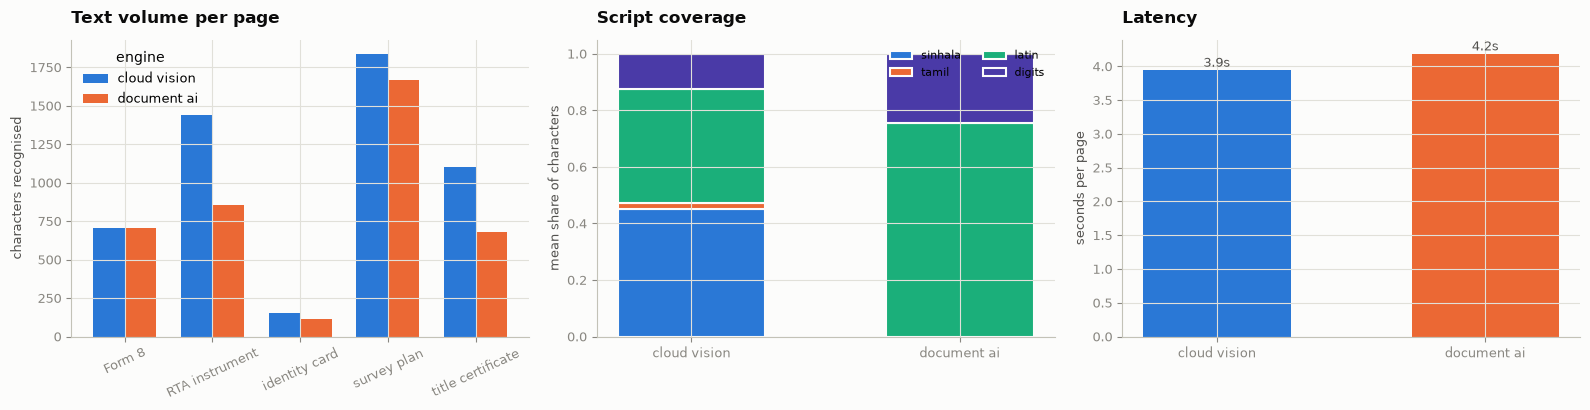

In [8]:
ok = compare[compare["status"] == "ok"]
if len(ok):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

    ax = axes[0]
    pivot = ok.pivot_table(index="document", columns="engine", values="chars")
    pivot.plot(kind="bar", ax=ax, color=[viz.SERIES[0], viz.SERIES[1]], width=0.72,
               legend=True, rot=25)
    ax.set_ylabel("characters recognised")
    ax.set_title("Text volume per page")
    ax.set_xlabel("")

    ax = axes[1]
    engines = sorted(ok["engine"].unique())
    x = np.arange(len(engines))
    bottom = np.zeros(len(engines))
    for i, part in enumerate(["sinhala", "tamil", "latin", "digits"]):
        vals = [ok[ok.engine == e][part].mean() for e in engines]
        ax.bar(x, vals, 0.55, bottom=bottom, color=viz.SERIES[i], label=part,
               edgecolor=viz.SURFACE, linewidth=1.5)
        bottom += np.array(vals)
    ax.set_xticks(x, engines)
    ax.set_ylabel("mean share of characters")
    ax.set_title("Script coverage")
    ax.legend(ncol=2, fontsize=8)

    ax = axes[2]
    secs = [ok[ok.engine == e]["seconds"].mean() for e in engines]
    ax.bar(x, secs, 0.55, color=[viz.SERIES[0], viz.SERIES[1]])
    for i, v in enumerate(secs):
        if not np.isnan(v):
            ax.text(i, v + 0.05, f"{v:.1f}s", ha="center", fontsize=9, color=viz.INK_2)
    ax.set_xticks(x, engines)
    ax.set_ylabel("seconds per page")
    ax.set_title("Latency")

    plt.tight_layout(); plt.show()

## Provenance: four-point polygons versus rectangles

Document AI returns a genuine quadrilateral per element. Vision's block geometry
is effectively axis-aligned. On a skewed scan the difference is real: a rectangle
drawn around rotated text necessarily includes neighbouring content, which is
exactly the "correct text, wrong region" failure the benchmark counts against
provenance.

Measured here as how far each polygon departs from its own bounding rectangle.

In [9]:
def skew_ratio(points: list[list[float]]) -> float:
    """1 - (polygon area / its bounding-rect area). 0 = perfectly axis-aligned."""
    if len(points) < 4:
        return 0.0
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    rect = (max(xs) - min(xs)) * (max(ys) - min(ys))
    if rect <= 0:
        return 0.0
    area = abs(sum(points[i][0] * points[(i + 1) % len(points)][1]
                   - points[(i + 1) % len(points)][0] * points[i][1]
                   for i in range(len(points)))) / 2
    return max(0.0, min(1.0, 1 - area / rect))


rows = []
for label, payload in docai.items():
    for level in ("blocks", "paragraphs", "tokens"):
        items = payload.get(level, [])
        if not items:
            continue
        skews = [skew_ratio(i["poly"]) for i in items]
        confs = [i["confidence"] for i in items if i.get("confidence") is not None]
        rows.append({"document": label, "level": level, "n": len(items),
                     "mean_skew": round(float(np.mean(skews)), 4),
                     "max_skew": round(float(np.max(skews)), 4),
                     "mean_confidence": round(float(np.mean(confs)), 4) if confs else None})

prov = pd.DataFrame(rows)
if prov.empty:
    print("no Document AI geometry available")
else:
    display(prov)
    print("mean_skew 0 means the polygon is already a rectangle, so the extra")
    print("precision of a 4-point polygon buys nothing on that page.")

,document,level,n,mean_skew,max_skew,mean_confidence
0,identity card,blocks,18,0.1678,0.4172,0.6140
1,identity card,paragraphs,18,0.1678,0.4172,0.6140
2,identity card,tokens,28,0.1174,0.4172,0.6440
3,survey plan,blocks,68,0.1017,0.4930,0.8416
4,survey plan,paragraphs,68,0.1017,0.4930,0.8416
5,survey plan,tokens,412,0.0383,0.3290,0.8267
6,title certificate,blocks,69,0.0968,0.5471,0.5556
7,title certificate,paragraphs,69,0.0968,0.5471,0.5556
8,title certificate,tokens,211,0.0524,0.5471,0.6062
9,Form 8,blocks,26,0.0946,0.2799,0.9420


mean_skew 0 means the polygon is already a rectangle, so the extra
precision of a 4-point polygon buys nothing on that page.


In [10]:
SHOW_INLINE = False    # True renders client pages into the notebook. Never commit that.

SCRIPT_COLOUR = {"sinhala": viz.SERIES[0], "tamil": viz.SERIES[1],
                 "latin": viz.SERIES[2], "numeric": viz.SERIES[3], "none": viz.MUTED}

for t in targets:
    payload = docai.get(t["label"])
    if not payload:
        continue
    page = render.render_doc(t["path"], dpi=DPI, variant=VARIANT, page_limit=t["page"])[t["page"] - 1]
    w, h = page.size
    fig, axes = plt.subplots(1, 2, figsize=(14, 9.5))

    ax = axes[0]
    ax.imshow(page.image)
    for token in payload["tokens"]:
        pts = [(p[0] * w, p[1] * h) for p in token["poly"]]
        if len(pts) >= 3:
            ax.add_patch(mpatches.Polygon(pts, closed=True, fill=False, linewidth=0.8,
                                          edgecolor=viz.SEQ_HUE))
    ax.set_title(f"tokens as 4-point polygons — {len(payload['tokens'])}", fontsize=10)

    ax = axes[1]
    ax.imshow(page.image)
    seen = []
    for para in payload["paragraphs"]:
        pts = [(p[0] * w, p[1] * h) for p in para["poly"]]
        if len(pts) < 3:
            continue
        seen.append(para["script"])
        ax.add_patch(mpatches.Polygon(pts, closed=True, fill=False, linewidth=1.6,
                                      edgecolor=SCRIPT_COLOUR.get(para["script"], viz.MUTED)))
    ax.set_title(f"paragraphs by recognised script — {len(payload['paragraphs'])}", fontsize=10)
    handles = [mpatches.Patch(color=SCRIPT_COLOUR[s], label=s)
               for s in dict.fromkeys(seen) if s in SCRIPT_COLOUR]
    if handles:
        ax.legend(handles=handles, loc="lower right", fontsize=8)

    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    fig.suptitle(f"Document AI — {t['label']} ({t['why']})", fontsize=12)
    dest = OVERLAYS / f"docai-{t['filename'][:30]}-p{t['page']}.png"
    fig.savefig(dest, dpi=85, bbox_inches="tight")
    plt.show() if SHOW_INLINE else plt.close(fig)
    page.image.close(); gc.collect()
    print("wrote", dest.name)

print(f"\noverlays in {OVERLAYS} (gitignored)")

findfont: Failed to find font weight 600, now using 700.


wrote docai-source-001-national-identity-c-p1.png
wrote docai-source-002-survey-plan-2338-lo-p1.png
wrote docai-source-003-title-certificate-p-p1.png
wrote docai-source-004-form8-instrument-of-p1.png
wrote docai-source-005-rta-sale-instrument-p1.png

overlays in D:\projects\Draftly-Project\draftly-research\ocr-benchmark\renders\overlays\docai (gitignored)


## Summary

### Tested

**OCR processor.** Returns everything asked for: full text, a four-level
structure (pages → blocks → paragraphs → lines → tokens), per-element confidence,
detected languages, and normalized four-point polygons. That is strictly more
structure than Cloud Vision exposes, and the token layer plus true quadrilaterals
are the parts a provenance-driven pipeline would actually use.

### Not tested, and not guessed at

**Form Parser** — no processor exists. Key–value recall, table extraction and
checkbox detection are unmeasured and no figure for them appears anywhere above.
It is also **20× the OCR price** ($30 vs $1.50 per 1000 pages), so it needs to
earn its place rather than be adopted by default.

**Custom Extractor** — no trained model. The schema is generated and written to
`schemas/documentai-custom-extractor-schema.json`, but training needs labelled
documents and this corpus has **four**. Google's guidance is ~10 per field
minimum. There is a circularity worth naming: the Custom Extractor is the tool
most likely to help, and it is blocked by the same missing labels that block
every other accuracy measurement in this benchmark.

### Caveats on the comparison

- Five pages, one matter, page 1 only. Fields on later pages are unreachable, so
  the recovery ceiling is well below 100% for both engines.
- Verbatim containment measures **coverage**, not correctness.
- Document AI shares a 2,000-page project budget with the corpus converter. This
  notebook reads that ledger but deliberately does not write to it, since it is a
  production artifact.
- Nothing here modifies the production pipeline.